# PD Analysis (Modular)

This notebook is a concise entry point. All heavy lifting lives in `pd_pipeline/`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd

from pd_pipeline import basel, capital, config, data, lasso, plots, portfolio, scenario, sensitivity


In [2]:
# Load and merge macro + GPR data
macro_frames = data.load_macro_data(
    gdp_path='../data/macro/global_gdp_monthly.csv',
    interest_path='../data/macro/intrest FRED.csv',
    unemployment_path='../data/macro/sweden_unemployment_monthly.csv',
    housing_path='../data/macro/Bostadspriser ScB 1997-2025_transposed.csv',
    cpi_path='../data/macro/global_cpi_monthly.csv',
    verbose=True,
)

df_gpr = data.load_gpr_data('../data/geopolitical/data_gpr_Data_GPR.csv', verbose=True)

df_merged = data.merge_macro_data(macro_frames, df_gpr)

# Covariance / correlation on unlagged variables only (used for scenario analysis)
cov_matrix, corr_matrix, mean_vector = data.summarize_macro_data(
    df_merged,
    config.ALL_PREDICTOR_COLS,
    verbose=True,
)

# Add t-1 … t-12 lags for all macro + GPR variables
df_merged = data.add_macro_lags(df_merged, config.MACRO_COLS + config.GPR_COLS, n_lags=config.N_LAGS)
print(f"df_merged now has {df_merged.shape[1]} columns ({config.N_LAGS} lags added per variable)")


Cleaned df_gdp head:
        Date  GDP_Growth
0 2012-01-01   95.266073
1 2012-02-01   95.453594
2 2012-03-01   95.641116
3 2012-04-01   95.828638
4 2012-05-01   95.974193

Cleaned df_interest head:
        Date  Interest_Rate
0 1954-07-01           0.80
1 1954-08-01           1.22
2 1954-09-01           1.07
3 1954-10-01           0.85
4 1954-11-01           0.83

Cleaned df_unemployment head:
        Date  Unemployment_Rate
0 1983-01-01                3.4
1 1983-02-01                3.7
2 1983-03-01                3.7
3 1983-04-01                3.4
4 1983-05-01                3.7

Cleaned df_housing head:
        Date  Housing_Prices
0 1997-01-01             749
1 1997-02-01             711
2 1997-03-01             746
3 1997-04-01             737
4 1997-05-01             738

Cleaned df_cpi head:
        Date     CPI    Asia  Americas  Europe
0 2011-01-01  80.843  79.189    84.751  85.512
1 2011-02-01  81.250  79.557    85.168  85.956
2 2011-03-01  81.726  79.710    85.901  86.571
3

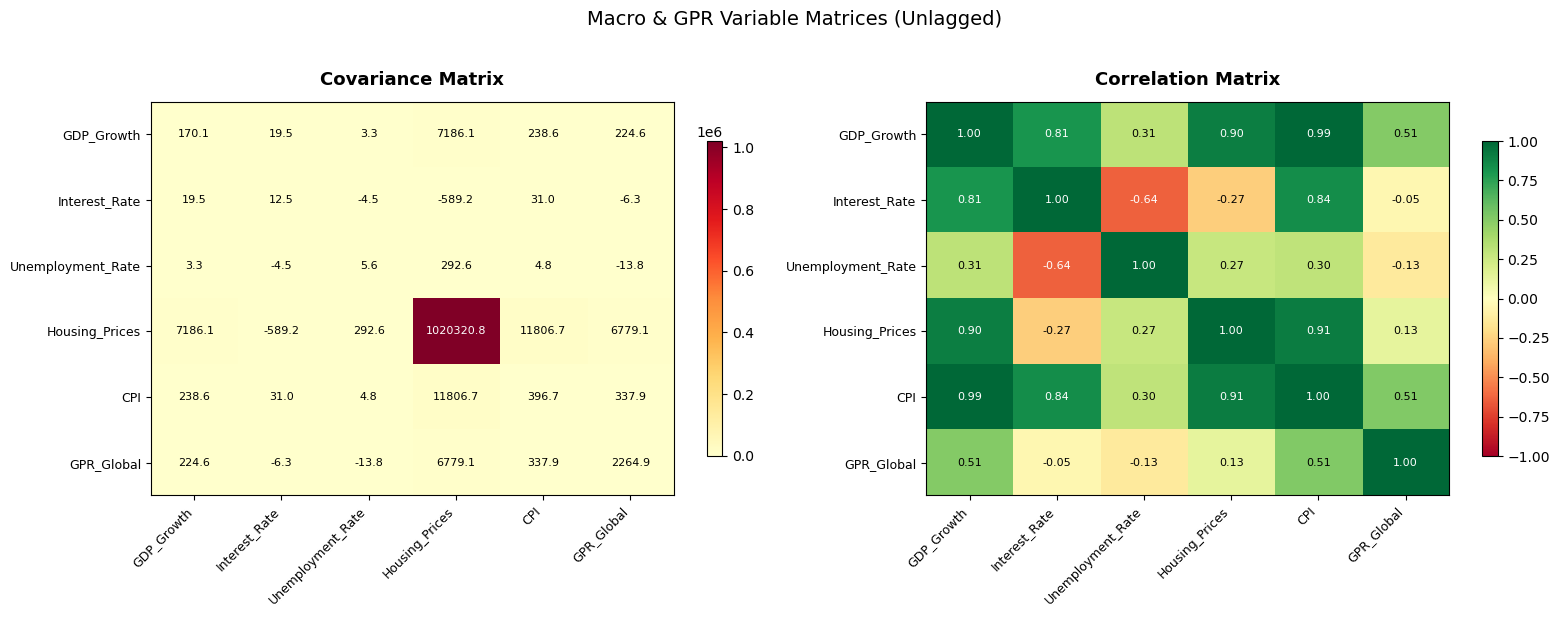

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, title in zip(
    axes,
    [cov_matrix, corr_matrix],
    ['Covariance Matrix', 'Correlation Matrix'],
):
    labels = matrix.columns.tolist()
    n = len(labels)
    vals = matrix.values

    vmax = 1.0 if 'Correlation' in title else None
    vmin = -1.0 if 'Correlation' in title else None
    cmap = 'RdYlGn' if 'Correlation' in title else 'YlOrRd'

    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, shrink=0.8)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

    for i in range(n):
        for j in range(n):
            v = vals[i, j]
            txt = f'{v:.2f}' if 'Correlation' in title else f'{v:.1f}'
            color = 'white' if abs(v) > (0.6 if 'Correlation' in title else 0.7 * vals.max()) else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

plt.suptitle('Macro & GPR Variable Matrices (Unlagged)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Regenerate pdsFitchData_SIC_div2.csv with correct SIC div2 sector classification
# (Re-run this cell whenever the base PD data or sector mapping changes)
data.build_sic_div2_pds_file(
    pds_path='../data/PDs/pdsFitchData.csv',
    isin_path='../data/PDs/ISIN_PD_DATA.csv',
    output_path='../data/PDs/pdsFitchData_SIC_div2.csv',
    verbose=True,
)

# Load PDs and merge with macro data
df_pds = data.load_pds_data('../data/PDs/pdsFitchData_SIC_div2.csv', verbose=True)

df_final = data.merge_pds_macro(df_pds, df_merged, verbose=True)

# Drop rows where any current or lagged predictor is missing (removes first ~12 months per series)
df_final_cleaned = data.prepare_model_data(
    df_final,
    config.ALL_PREDICTOR_COLS_WITH_LAGS,
    sector_col=config.SECTOR_COL,
    verbose=True,
)


✓ Saved 49,022 rows to ../data/PDs/pdsFitchData_SIC_div2.csv

Sector distribution:
Sector
Finance, Insurance & Real Estate        12376
Heavy Manufacturing                      6858
Utilities                                5694
Light Manufacturing                      5657
Communications                           5268
Mining & Construction                    3104
Services                                 2914
Wholesale & Retail Trade                 2831
Unassigned                               1535
Transportation                           1444
Health, Legal & Educational Services      982
Public Administration                     359

Columns in df_pds: ['Company_number', 'Date', '12_month', 'Sector', 'PDzero']

First few rows of df_pds:
       Company_number       Date  12_month          Sector  PDzero
39773      80095907.0 2012-06-01    0.0050  Communications   0.005
39774      80095907.0 2012-06-01    0.0137  Communications   0.005
39775      80095907.0 2012-06-01    0.0137  Communi

In [5]:
# Export cleaned dataset for reuse
data.export_dataframe(df_final_cleaned, output_file='df_final_cleaned.csv', verbose=True)


✓ Successfully exported dataframe to: df_final_cleaned.csv
  - Rows: 49,022
  - Columns: 38
  - File size: 17.08 MB (approximate)


In [6]:
# ── df_final_cleaned verification ────────────────────────────────────────────
print("=" * 60)
print("df_final_cleaned  –  DATA VERIFICATION")
print("=" * 60)

print(f"\nShape : {df_final_cleaned.shape[0]:,} rows × {df_final_cleaned.shape[1]} columns")
print(f"Date range : {df_final_cleaned['Date'].min().date()}  →  {df_final_cleaned['Date'].max().date()}")
print(f"Companies  : {df_final_cleaned['Company_number'].nunique():,} unique")

if 'Sector' in df_final_cleaned.columns:
    print(f"\nSector distribution:")
    print(df_final_cleaned['Sector'].value_counts().to_string())

print("\nMissing values per column:")
missing = df_final_cleaned.isnull().sum()
missing = missing[missing > 0]
print(missing.to_string() if not missing.empty else "  None")

macro_cols = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate', 'Housing_Prices', 'CPI',
              'GPR_Global']
available_macro = [c for c in macro_cols if c in df_final_cleaned.columns]
print(f"\nMacro summary ({', '.join(available_macro)}):")
print(df_final_cleaned[available_macro].describe().round(3).to_string())

print(f"\nPD (12_month) summary:")
print(df_final_cleaned['12_month'].describe().round(6).to_string())

print(f"\nFirst 5 rows:")
display_cols = ['Date', 'Company_number'] + (['Sector'] if 'Sector' in df_final_cleaned.columns else []) + ['12_month'] + available_macro[:3]
print(df_final_cleaned[display_cols].head(5).to_string(index=False))

df_final_cleaned  –  DATA VERIFICATION

Shape : 49,022 rows × 38 columns
Date range : 2012-06-01  →  2024-07-01
Companies  : 2,304 unique

Sector distribution:
Sector
Finance, Insurance & Real Estate        12376
Heavy Manufacturing                      6858
Utilities                                5694
Light Manufacturing                      5657
Communications                           5268
Mining & Construction                    3104
Services                                 2914
Wholesale & Retail Trade                 2831
Unassigned                               1535
Transportation                           1444
Health, Legal & Educational Services      982
Public Administration                     359

Missing values per column:
12_month    12157

Macro summary (GDP_Growth, Interest_Rate, Unemployment_Rate, Housing_Prices, CPI, GPR_Global):
       GDP_Growth  Interest_Rate  Unemployment_Rate  Housing_Prices        CPI  GPR_Global
count   49022.000      49022.000          49022.

In [7]:
# OLS sensitivity analysis (includes current + lagged macro/GPR variables)

df_sensitivities = sensitivity.run_sensitivity_analysis(
    df_final_cleaned,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=True,
)

print("\n" + "="*80)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*80)
print(df_sensitivities)



Processing sector: Communications (n=5268)
  ✓ 12_month: R²=0.156, N=3926

Processing sector: Utilities (n=5694)
  ✓ 12_month: R²=0.178, N=4245

Processing sector: Mining & Construction (n=3104)
  ✓ 12_month: R²=0.179, N=2347

Processing sector: Light Manufacturing (n=5657)


  ✓ 12_month: R²=0.048, N=4204



Processing sector: Heavy Manufacturing (n=6858)


  ✓ 12_month: R²=0.186, N=5433

Processing sector: Public Administration (n=359)
  ✓ 12_month: R²=0.410, N=251

Processing sector: Services (n=2914)
  ✓ 12_month: R²=0.081, N=2167

Processing sector: Health, Legal & Educational Services (n=982)
  ✓ 12_month: R²=0.242, N=720

Processing sector: Finance, Insurance & Real Estate (n=12376)


  ✓ 12_month: R²=0.109, N=9299

Processing sector: Unassigned (n=1535)
  ✓ 12_month: R²=0.446, N=1191

Processing sector: Wholesale & Retail Trade (n=2831)
  ✓ 12_month: R²=0.055, N=1949

Processing sector: Transportation (n=1444)
  ✓ 12_month: R²=0.144, N=1133

SENSITIVITY ANALYSIS RESULTS


                                  Sector PD_Horizon  Intercept  \
0                         Communications   12_month   0.489175   
1                              Utilities   12_month   2.514074   
2                  Mining & Construction   12_month   3.659989   
3                    Light Manufacturing   12_month   0.270576   
4                    Heavy Manufacturing   12_month  -0.576979   
5                  Public Administration   12_month  -1.436998   
6                               Services   12_month   0.201331   
7   Health, Legal & Educational Services   12_month  -3.423016   
8       Finance, Insurance & Real Estate   12_month  -4.730502   
9                             Unassigned   12_month -12.019600   
10              Wholesale & Retail Trade   12_month  -3.477699   
11                        Transportation   12_month -11.990211   

    N_observations  R_squared  β_GDP_Growth  β_GDP_Growth_CI_lower  \
0             3926   0.156124      2.222337               1.624423   
1

In [8]:
# Sensitivity exports + tables
sensitivity.export_sensitivities(df_sensitivities, output_file='sensitivity_results_with_CI.csv')

sensitivity.print_sensitivity_tables(df_sensitivities, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)

sensitivity.print_confidence_interval_summary(df_sensitivities, config.ALL_GPR_COLS)

# Uncomment for a full per-sector printout (very verbose)
# sensitivity.print_sensitivity_details(df_sensitivities, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)


✓ Sensitivity results with 95% confidence intervals exported to: sensitivity_results_with_CI.csv
  Total sectors analyzed: 12

Columns include:
  - Point estimates: β_[variable] and δ_[variable]
  - 95% CI lower bounds: β_[variable]_CI_lower and δ_[variable]_CI_lower
  - 95% CI upper bounds: β_[variable]_CI_upper and δ_[variable]_CI_upper
MACRO SENSITIVITIES (β) - Impact of macroeconomic variables on PD
                                  Sector PD_Horizon  N_observations  \
0                         Communications   12_month            3926   
1                              Utilities   12_month            4245   
2                  Mining & Construction   12_month            2347   
3                    Light Manufacturing   12_month            4204   
4                    Heavy Manufacturing   12_month            5433   
5                  Public Administration   12_month             251   
6                               Services   12_month            2167   
7   Health, Legal & Educa

In [9]:
# LASSO feature selection (includes current + lagged macro/GPR variables)

df_lasso, lasso_selected_features = lasso.run_lasso_feature_selection(
    df_final_cleaned,
    macro_cols=config.ALL_MACRO_COLS,
    gpr_cols=config.ALL_GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=True,
)

feature_freq_df = lasso.print_lasso_summary(df_lasso, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
comparison_full = lasso.compare_ols_lasso(df_sensitivities, df_lasso, config.ALL_MACRO_COLS, config.ALL_GPR_COLS)
lasso.export_lasso_outputs(df_lasso, comparison_full)
lasso.print_feature_recommendations(feature_freq_df, comparison_full)


LASSO FEATURE SELECTION - IDENTIFYING IMPORTANT FACTORS

Performing LASSO with 5-fold cross-validation to select optimal regularization...

Sector: Communications (n=5268)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.975e-01, tolerance: 3.966e-01
  model = cd_fast.enet_coordinate_descent_gram(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.236e-01, tolerance: 5.140e-01
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.691e-01, tolerance: 5.140e-01
  model = cd_fast.enet_coordinate_descent_gram(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.173e+00, tolerance: 5.140e-01
  model = cd_fast.enet_coordinate_descent_gram(


...


12_month:
  Optimal alpha: 0.014867
  R²: 0.342
  Features selected: 12/30

  Selected features (non-zero coefficients):
    Interest_Rate            :  -0.9889
    Unemployment_Rate        :  -0.1997
    Housing_Prices           :  -0.1634
    GDP_Growth_lag4          :   0.1079
    Interest_Rate_lag2       :   1.4012
    Unemployment_Rate_lag2   :   0.2167
    Unemployment_Rate_lag3   :  -0.1105
    GPR_Global               :   0.0879
    GPR_Global_lag1          :   0.0389
    GPR_Global_lag2          :  -0.0734
    GPR_Global_lag3          :   0.1705
    GPR_Global_lag4          :  -0.1239

  Dropped features (zero coefficients):
    GDP_Growth               : 0.0000
    CPI                      : 0.0000
    GDP_Growth_lag1          : 0.0000
    GDP_Growth_lag2          : 0.0000
    GDP_Growth_lag3          : 0.0000
    Interest_Rate_lag1       : 0.0000
    Interest_Rate_lag3       : 0.0000
    Interest_Rate_lag4       : 0.0000
    Unemployment_Rate_lag1   : 0.0000
    Unemploymen

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



12_month:
  Optimal alpha: 0.153466
  R²: 0.000
  Features selected: 0/30
  No features selected (all coefficients shrunk to zero)

  Dropped features (zero coefficients):
    GDP_Growth               : 0.0000
    Interest_Rate            : 0.0000
    Unemployment_Rate        : 0.0000
    Housing_Prices           : 0.0000
    CPI                      : 0.0000
    GDP_Growth_lag1          : 0.0000
    GDP_Growth_lag2          : 0.0000
    GDP_Growth_lag3          : 0.0000
    GDP_Growth_lag4          : 0.0000
    Interest_Rate_lag1       : 0.0000
    Interest_Rate_lag2       : 0.0000
    Interest_Rate_lag3       : 0.0000
    Interest_Rate_lag4       : 0.0000
    Unemployment_Rate_lag1   : 0.0000
    Unemployment_Rate_lag2   : 0.0000
    Unemployment_Rate_lag3   : 0.0000
    Unemployment_Rate_lag4   : 0.0000
    Housing_Prices_lag1      : 0.0000
    Housing_Prices_lag2      : 0.0000
    Housing_Prices_lag3      : 0.0000
    Housing_Prices_lag4      : 0.0000
    CPI_lag1                 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



12_month:
  Optimal alpha: 0.152970
  R²: 0.042
  Features selected: 5/30

  Selected features (non-zero coefficients):
    Housing_Prices           :   0.0662
    Unemployment_Rate_lag2   :   0.0273
    Unemployment_Rate_lag3   :   0.0187
    Unemployment_Rate_lag4   :   0.0428
    Housing_Prices_lag2      :   0.0960

  Dropped features (zero coefficients):
    GDP_Growth               : 0.0000
    Interest_Rate            : 0.0000
    Unemployment_Rate        : 0.0000
    CPI                      : 0.0000
    GDP_Growth_lag1          : 0.0000
    GDP_Growth_lag2          : 0.0000
    GDP_Growth_lag3          : 0.0000
    GDP_Growth_lag4          : 0.0000
    Interest_Rate_lag1       : 0.0000
    Interest_Rate_lag2       : 0.0000
    Interest_Rate_lag3       : 0.0000
    Interest_Rate_lag4       : 0.0000
    Unemployment_Rate_lag1   : 0.0000
    Housing_Prices_lag1      : 0.0000
    Housing_Prices_lag3      : 0.0000
    Housing_Prices_lag4      : 0.0000
    CPI_lag1                 :

Plotting 10 sectors (top 20 by observation count)


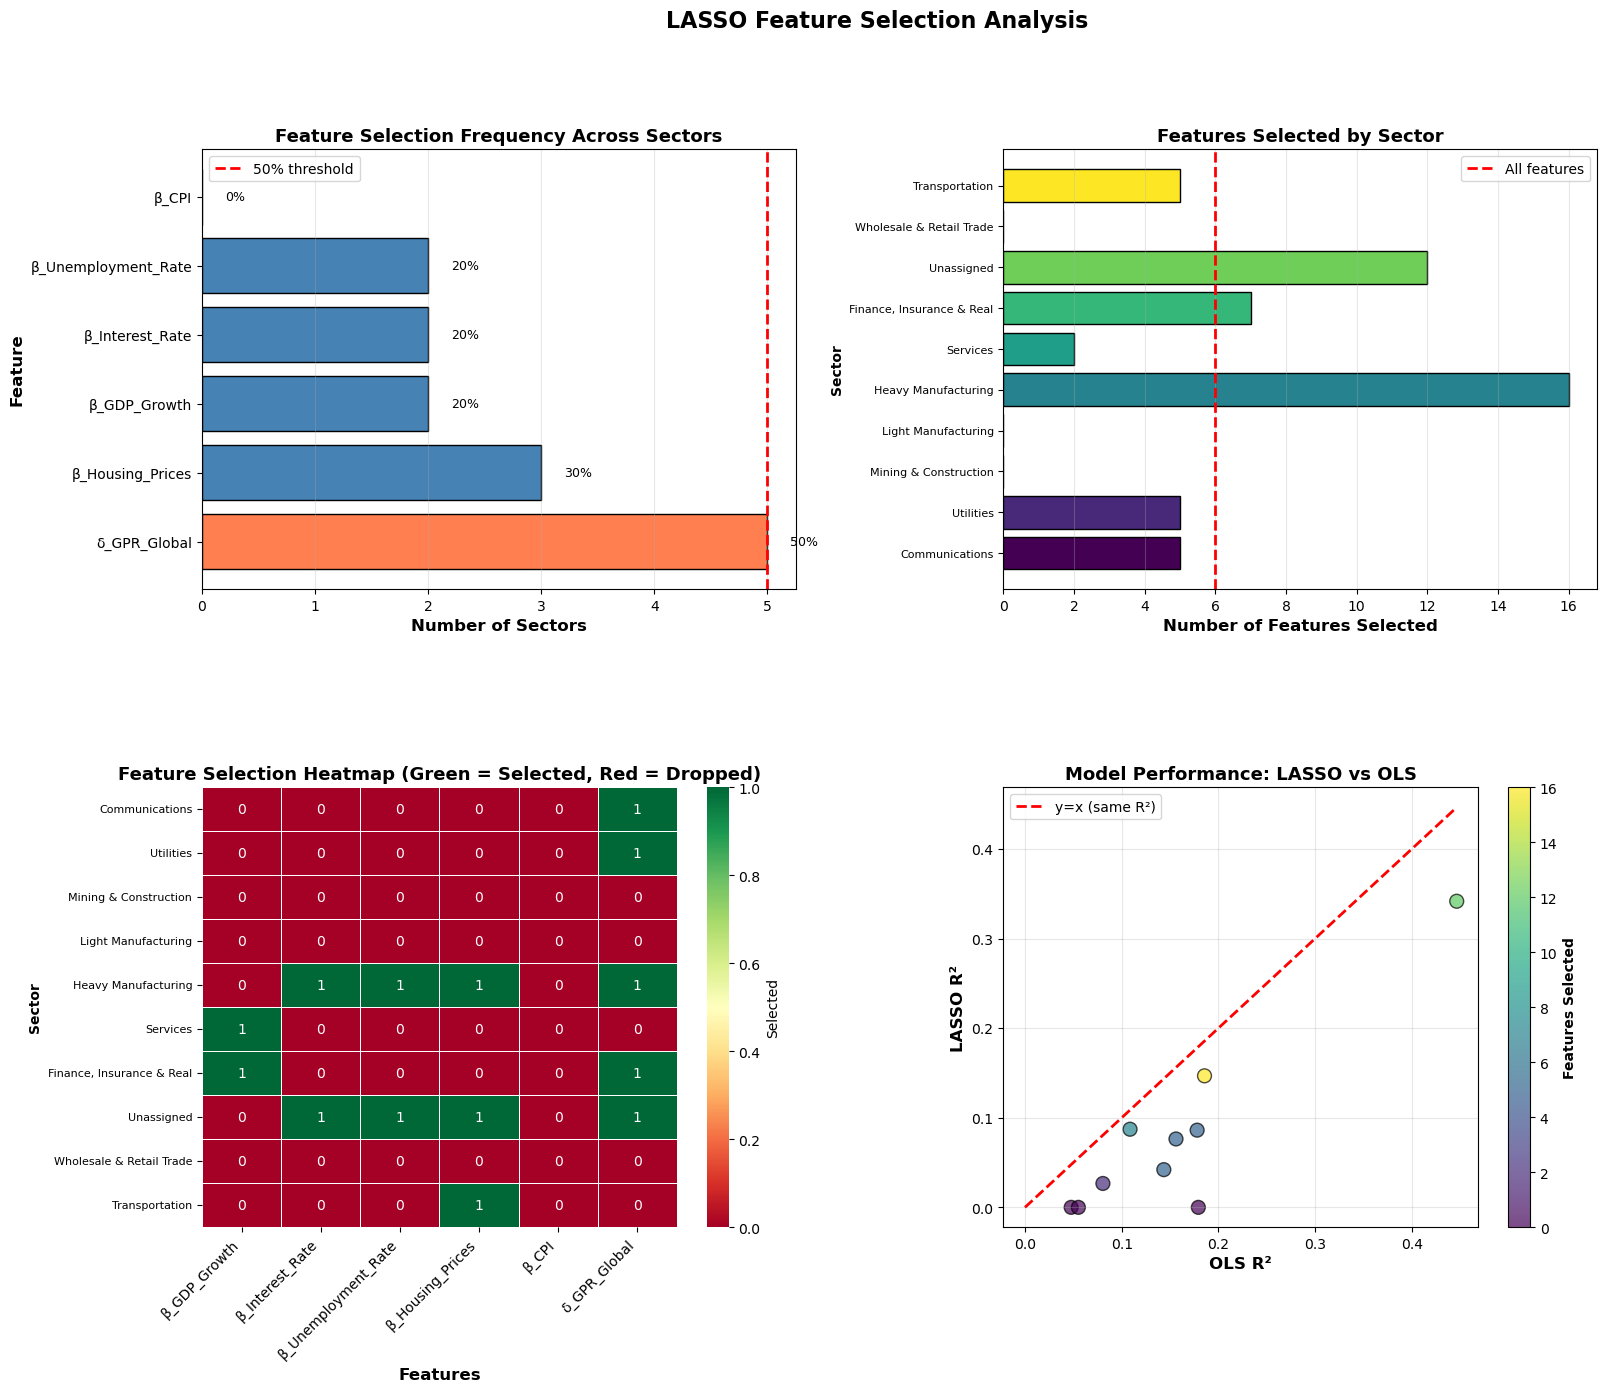

In [10]:
# LASSO visualizations
plots.plot_lasso_summary(df_lasso, feature_freq_df, config.MACRO_COLS, config.GPR_COLS, df_sensitivities)
